# Week 4 — Variational Quantum Circuits, the Parameter-Shift Rule, and PennyLane

**Quantum Artificial Intelligence**

---

The algorithms of Week 3 were *fixed* circuits with provable speedups, designed for fault-tolerant
hardware. Today's noisy quantum devices favor a different paradigm: **variational quantum circuits** —
parameterized circuits whose gate angles are *trained* by a classical optimizer, exactly like a neural
network. This is the foundation of near-term quantum machine learning, and it is where this course's
themes of optimization and learning meet quantum computing.

This week we (1) build a variational circuit on our from-scratch simulator, (2) derive the
**parameter-shift rule** — the exact analytic gradient of a quantum circuit, the quantum analogue of
backpropagation — and (3) bridge to **PennyLane**, confirming it reproduces what we built. We close
with the **variational quantum eigensolver (VQE)**, the flagship near-term algorithm, finding a
molecule-like Hamiltonian's ground-state energy.

Roadmap:

1. **Parameterized circuits** and the expectation-value cost function.
2. The **parameter-shift rule**: exact gradients without finite differences.
3. **The PennyLane bridge**: the same circuit, with autodiff and hardware back-ends.
4. **VQE**: minimizing $\langle\psi(\theta)|H|\psi(\theta)\rangle$ to find a ground-state energy.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

ket0 = np.array([1, 0], dtype=complex)
I2 = np.eye(2, dtype=complex)
X = np.array([[0,1],[1,0]], dtype=complex)
Y = np.array([[0,-1j],[1j,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)
def kron_all(ms): return reduce(np.kron, ms)
def Ry(t): return np.array([[np.cos(t/2), -np.sin(t/2)],[np.sin(t/2), np.cos(t/2)]], dtype=complex)
def Rz(t): return np.array([[np.exp(-1j*t/2),0],[0,np.exp(1j*t/2)]], dtype=complex)
CNOT = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)


## 1. Parameterized circuits and the cost function

A **variational circuit** (or *ansatz*) is a unitary $U(\theta)$ built from gates with tunable
parameters $\theta = (\theta_1, \dots, \theta_p)$ — typically rotation gates — interleaved with fixed
entangling gates. Applied to $|0\dots0\rangle$ it prepares a parameterized state
$|\psi(\theta)\rangle = U(\theta)|0\rangle$.

We extract a real number by measuring the expectation value of an **observable** $H$ (a Hermitian
operator):

$$
C(\theta) = \langle\psi(\theta)|\, H\, |\psi(\theta)\rangle .
$$

This scalar is our **cost function**. Training means finding $\theta^\*$ that minimizes (or maximizes)
$C$. Everything hinges on computing $\nabla_\theta C$ efficiently — the subject of Section 2. First we
build a concrete two-qubit ansatz and evaluate its cost.


In [2]:
def ansatz_state(theta, n=2):
    # A simple hardware-efficient ansatz: a layer of Ry, an entangler, another layer of Ry.
    # theta has length 2*n (one Ry angle per qubit per layer, 2 layers).
    state = kron_all([ket0]*n)
    # layer 1: Ry on each qubit
    for q in range(n):
        state = op_on(n, Ry(theta[q]), q) @ state
    # entangle: CNOT chain
    state = apply_cnot(state, 0, 1, n)
    # layer 2: Ry on each qubit
    for q in range(n):
        state = op_on(n, Ry(theta[n+q]), q) @ state
    return state

def op_on(n, gate, target):
    return kron_all([gate if w==target else I2 for w in range(n)])

def apply_cnot(state, control, target, n):
    # Build an n-qubit CNOT for adjacent (0,1) on 2 qubits (sufficient here).
    return CNOT @ state

def cost(theta, H):
    psi = ansatz_state(theta)
    return np.vdot(psi, H @ psi).real

# Observable: H = Z (x) Z  (favored by anti-correlated / correlated states)
H_zz = np.kron(Z, Z)
theta0 = np.array([0.3, 1.1, 0.7, 2.0])
print("cost at theta0:", cost(theta0, H_zz))
print("state at theta0:", np.round(ansatz_state(theta0), 4))


cost at theta0: -0.5633865039690125
state at theta0: [ 0.0416+0.j  0.8825+0.j -0.054 +0.j  0.4654+0.j]


## 2. The parameter-shift rule

How do we differentiate $C(\theta)$? Finite differences are noisy and biased. Remarkably, for circuits
built from rotation gates $R(\theta)=e^{-i\theta P/2}$ with $P^2=I$ (true for Pauli generators), the
gradient is **exact** and computed by evaluating the *same circuit* at two shifted parameter values:

$$
\boxed{\;\frac{\partial C}{\partial \theta_j} = \frac{1}{2}\Big[\,C\big(\theta + \tfrac{\pi}{2}e_j\big) - C\big(\theta - \tfrac{\pi}{2}e_j\big)\,\Big]\;}
$$

This is the **parameter-shift rule**. It is not an approximation: the shift is a macroscopic $\pi/2$,
not an infinitesimal $\epsilon$. The reason is that $C$ depends on each $\theta_j$ sinusoidally (a
consequence of $P^2=I$), and the derivative of a sinusoid is recovered exactly from two samples a
quarter-period apart. On real hardware, where we only have access to circuit *evaluations*, this is the
practical way to get gradients — the quantum counterpart of backpropagation. We verify it against
finite differences.


In [3]:
def parameter_shift_grad(theta, H):
    grad = np.zeros_like(theta)
    for j in range(len(theta)):
        shift = np.zeros_like(theta); shift[j] = np.pi/2
        grad[j] = 0.5*(cost(theta+shift, H) - cost(theta-shift, H))
    return grad

def finite_diff_grad(theta, H, eps=1e-6):
    grad = np.zeros_like(theta)
    for j in range(len(theta)):
        e = np.zeros_like(theta); e[j] = eps
        grad[j] = (cost(theta+e, H) - cost(theta-e, H))/(2*eps)
    return grad

g_ps = parameter_shift_grad(theta0, H_zz)
g_fd = finite_diff_grad(theta0, H_zz)
print("parameter-shift gradient:", g_ps)
print("finite-difference gradient:", g_fd)
print("max abs difference:", np.max(np.abs(g_ps - g_fd)))
print("=> parameter-shift is EXACT (matches finite diff to numerical precision)")


parameter-shift gradient: [ 0.7428 -0.0177  0.8259 -0.1237]
finite-difference gradient: [ 0.7428 -0.0177  0.8259 -0.1237]
max abs difference: 2.259006315341594e-10
=> parameter-shift is EXACT (matches finite diff to numerical precision)


The parameter-shift gradient matches finite differences to machine precision — but unlike finite
differences it is exact and robust to the shot noise of real measurements. With gradients in hand, we
can train a variational circuit by ordinary gradient descent. Let us minimize $\langle Z\otimes Z\rangle$.


initial cost: -0.5633865039690125
final cost: -1.0  (minimum of <ZZ> is -1)


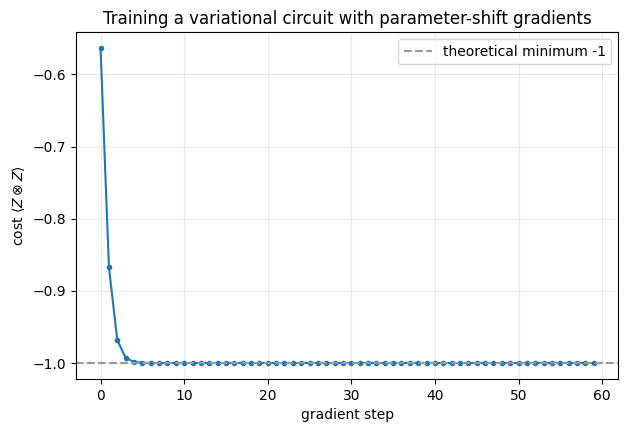

In [4]:
theta = np.array([0.3, 1.1, 0.7, 2.0])
lr = 0.3; history = []
for step in range(60):
    c = cost(theta, H_zz); history.append(c)
    theta = theta - lr * parameter_shift_grad(theta, H_zz)

print("initial cost:", history[0])
print("final cost:", history[-1], " (minimum of <ZZ> is -1)")

plt.figure()
plt.plot(history, "o-", ms=3)
plt.axhline(-1, color="0.6", ls="--", label="theoretical minimum -1")
plt.xlabel("gradient step"); plt.ylabel(r"cost $\langle Z\otimes Z\rangle$")
plt.title("Training a variational circuit with parameter-shift gradients")
plt.legend(); plt.show()


The circuit trains to the minimum $\langle Z\otimes Z\rangle = -1$, preparing a state in which the two
qubits are perfectly anti-correlated in the $Z$ basis. We did this with gradients computed *only* from
circuit evaluations — the same way it would work on quantum hardware.

## 3. The PennyLane bridge

Hand-coding ansätze and shift rules does not scale. **PennyLane** is a framework that defines quantum
circuits as differentiable functions: you write the gates, and it provides gradients (via the
parameter-shift rule we just derived) and integrates with classical optimizers and hardware back-ends.
We now rebuild the *exact same* computation in PennyLane and confirm it agrees with our from-scratch
results — making the bridge explicit.


In [5]:
import pennylane as qml
from pennylane import numpy as pnp

dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def pl_circuit(theta):
    # Same ansatz: Ry layer, CNOT, Ry layer; measure <Z(x)Z>
    qml.RY(theta[0], wires=0)
    qml.RY(theta[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(theta[2], wires=0)
    qml.RY(theta[3], wires=1)
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

theta_pl = pnp.array([0.3, 1.1, 0.7, 2.0], requires_grad=True)
print("PennyLane cost:   ", float(pl_circuit(theta_pl)))
print("from-scratch cost:", cost(np.array([0.3,1.1,0.7,2.0]), H_zz))

# PennyLane gradient (uses parameter-shift under the hood) vs ours
g_pl = qml.grad(pl_circuit)(theta_pl)
print("\nPennyLane gradient:   ", np.array(g_pl))
print("from-scratch (shift): ", parameter_shift_grad(np.array([0.3,1.1,0.7,2.0]), H_zz))
print("\n=> PennyLane reproduces our simulator and our gradient rule exactly.")


PennyLane cost:    -0.5633865039690125
from-scratch cost: -0.5633865039690125

PennyLane gradient:    [ 0.7428 -0.0177  0.8259 -0.1237]
from-scratch (shift):  [ 0.7428 -0.0177  0.8259 -0.1237]

=> PennyLane reproduces our simulator and our gradient rule exactly.


PennyLane's cost and gradient match our from-scratch implementation to numerical precision: the
framework is doing exactly what we built, just automated and scalable. From here we can use PennyLane's
optimizers, deeper ansätze, and hardware devices without losing sight of the mechanics underneath.

## 4. The variational quantum eigensolver (VQE)

The **VQE** is the flagship near-term quantum algorithm. Its goal: find the **ground-state energy** —
the lowest eigenvalue — of a Hamiltonian $H$, a central problem in quantum chemistry and materials. The
variational principle guarantees that for any state,

$$
\langle\psi(\theta)|H|\psi(\theta)\rangle \ge E_0 \quad(\text{the true ground-state energy}),
$$

so **minimizing** the cost drives the circuit toward the ground state. We use a model two-qubit
Hamiltonian (of the form arising for the $H_2$ molecule in a minimal basis),

$$
H = a\,Z_0 + b\,Z_1 + c\,Z_0 Z_1 + d\,X_0 X_1,
$$

train the ansatz with PennyLane's gradient-descent optimizer, and compare the result to the exact
ground-state energy from direct diagonalization.


exact ground-state energy (diagonalization): -0.6544003745317531


VQE final energy: -0.6540685728762505
error vs exact: 0.0003318016555026171


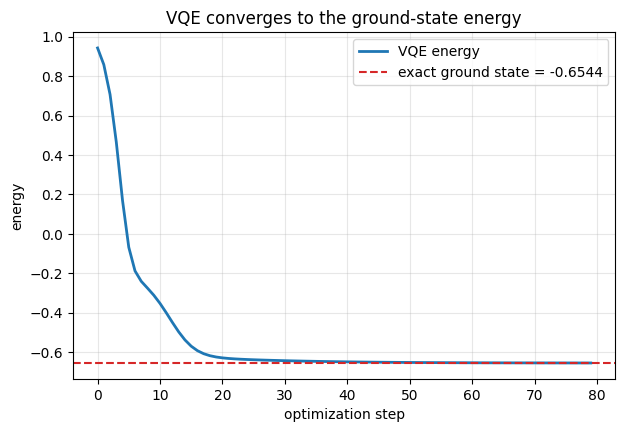

In [6]:
# Model Hamiltonian coefficients (illustrative, H2-like)
a, b, c, d = 0.4, 0.4, 0.2, 0.3
H_mol = (a*np.kron(Z, I2) + b*np.kron(I2, Z) + c*np.kron(Z, Z) + d*np.kron(X, X))
E_exact = np.min(np.linalg.eigvalsh(H_mol))
print("exact ground-state energy (diagonalization):", E_exact)

coeffs = [a, b, c, d]
obs = [qml.PauliZ(0), qml.PauliZ(1), qml.PauliZ(0) @ qml.PauliZ(1), qml.PauliX(0) @ qml.PauliX(1)]
H_pl = qml.Hamiltonian(coeffs, obs)

@qml.qnode(dev)
def vqe_circuit(theta):
    qml.RY(theta[0], wires=0); qml.RY(theta[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(theta[2], wires=0); qml.RY(theta[3], wires=1)
    return qml.expval(H_pl)

theta = pnp.array([0.1, 0.2, 0.3, 0.4], requires_grad=True)
opt = qml.GradientDescentOptimizer(stepsize=0.4)
energies = []
for step in range(80):
    theta, e = opt.step_and_cost(vqe_circuit, theta)
    energies.append(float(e))

print("VQE final energy:", energies[-1])
print("error vs exact:", abs(energies[-1] - E_exact))

plt.figure()
plt.plot(energies, lw=2, label="VQE energy")
plt.axhline(E_exact, color="C3", ls="--", label=f"exact ground state = {E_exact:.4f}")
plt.xlabel("optimization step"); plt.ylabel("energy")
plt.title("VQE converges to the ground-state energy"); plt.legend(); plt.show()


The VQE converges to the exact ground-state energy obtained by diagonalization, confirming both the
variational principle and our PennyLane implementation. For two qubits we could of course diagonalize
directly; the point is that the VQE needs only to *prepare states and measure energies*, so it scales to
systems far too large to diagonalize classically — which is why it is a leading candidate for quantum
advantage in chemistry. This same variational machinery, with a data-dependent circuit, becomes a
**machine learning model** in Week 5.

## 5. Summary

- A **variational circuit** $U(\theta)$ prepares a parameterized state; measuring an observable gives a
  trainable cost $C(\theta)=\langle\psi(\theta)|H|\psi(\theta)\rangle$.
- The **parameter-shift rule** computes exact gradients from circuit evaluations at $\theta\pm\pi/2$ —
  the quantum analogue of backpropagation — which we verified against finite differences and used to
  train a circuit.
- **PennyLane** automates exactly this: we confirmed it reproduces our from-scratch cost and gradient,
  then used it for scalable training.
- The **VQE** minimizes an energy expectation to find a Hamiltonian's ground state, converging to the
  exact value on a model molecule.

In Week 5 we turn variational circuits into **machine learning models**: encoding classical data into
quantum states and training a variational quantum classifier, while confronting the practical challenge
of **barren plateaus**.


## 6. Exercises

**Exercise 1 (sinusoidal cost).** Fix all but one parameter and plot $C(\theta_j)$ over a full period.
Confirm it is a pure sinusoid and that the parameter-shift rule returns its exact derivative at several
points.

**Exercise 2 (deeper ansatz).** Add a second entangling layer to the ansatz and retrain the VQE. Does
the extra expressivity lower the achievable energy for a harder Hamiltonian (try larger $d$)?

**Exercise 3 (optimizer comparison).** Replace gradient descent with PennyLane's `AdamOptimizer` and
`QNGOptimizer` (quantum natural gradient). Compare convergence speed on the VQE task.

**Exercise 4 (real molecule).** Use PennyLane's `qml.qchem` module to build the actual $H_2$ Hamiltonian
at bond length 0.74 Å and run VQE. Compare the energy curve across bond lengths to the known
dissociation curve.


In [7]:
# Scratch space for the exercises.
